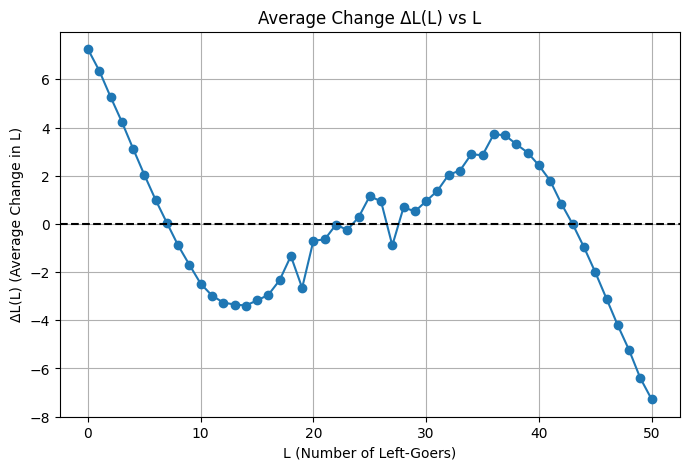

In [1]:
import numpy as np
import matplotlib.pyplot as plt

C = 0.5        # Length of the circular track
v = 0.01       # Velocity of agents per timestep
r = 0.045      # Interaction radius
N = 50         # Number of agents
P = 0.15       # Probability of random direction flip
T_warmup = 100 # Timesteps to reach steady state before measurement
T_measure = 20 # Number of timesteps to measure ΔL after warmup
runs = 5000   # Number of simulation runs to average over

# -----------------------------
# Preallocate result accumulators
# -----------------------------
delta_sum = np.zeros(N + 1)  # Sum of ΔL values for each possible L (number of left-goers)
count = np.zeros(N + 1)      # Count of observations for each L

# -----------------------------
# Main Simulation Loop
# -----------------------------
for run in range(runs):
    # Initialize agents with random positions on the ring [0, C)
    positions = np.random.uniform(0, C, N)
    
    # Random initial directions: -1 (left) or 1 (right)
    directions = np.random.choice([-1, 1], N)

    # Initial number of agents going left
    L_prev = np.count_nonzero(directions == -1)

    for t in range(T_warmup + T_measure):
        # Compute pairwise circular distances between all agents
        pos_diff = positions[:, None] - positions
        distances = np.abs(pos_diff)
        distances = np.minimum(distances, C - distances)  # Handle circular boundary

        # -----------------------------
        # Update directions based on neighbor influence
        # -----------------------------
        influence = np.zeros(N)
        for i in range(N):
            neighbors = distances[i] <= r  # Neighbors within interaction radius
            local_sum = np.sum(directions[neighbors])  # Net direction of neighbors

            # Update direction with probabilistic rule
            if np.random.rand() < P:
                influence[i] = -directions[i]  # Random flip
            elif local_sum != 0:
                influence[i] = np.sign(local_sum)  # Follow majority direction
            else:
                influence[i] = directions[i]  # Keep same direction

        # Update directions and positions
        directions = influence.astype(int)
        positions = (positions + v * directions) % C  # Move and wrap around circle

        # -----------------------------
        # Measurement Phase
        # -----------------------------
        L_curr = np.count_nonzero(directions == -1)  # Current number of left-goers

        if t >= T_warmup:
            delta = L_curr - L_prev  # Change in number of left-goers
            delta_sum[L_prev] += delta  # Accumulate ΔL
            count[L_prev] += 1          # Count how many times L_prev occurred

        L_prev = L_curr  # Update for next timestep

# Avoid division by zero
nonzero_mask = count > 0
L_vals = np.arange(N + 1)[nonzero_mask]          # L values with nonzero measurements
avg_deltaL = delta_sum[nonzero_mask] / count[nonzero_mask]  # Compute average ΔL


# Save Results to File

with open("L_of_L.txt", "w") as f:
    for L, dL in zip(L_vals, avg_deltaL):
        f.write(f"{L} {dL}\n")

plt.figure(figsize=(8, 5))
plt.plot(L_vals, avg_deltaL, marker='o')
plt.axhline(0, color='black', linestyle='--')  # Reference line at ΔL = 0
plt.xlabel("L (Number of Left-Goers)")
plt.ylabel("ΔL(L) (Average Change in L)")
plt.title("Average Change ΔL(L) vs L")
plt.grid(True)
plt.show()


Fitted φ (phi): 1.0000
Fitted c: 0.1607


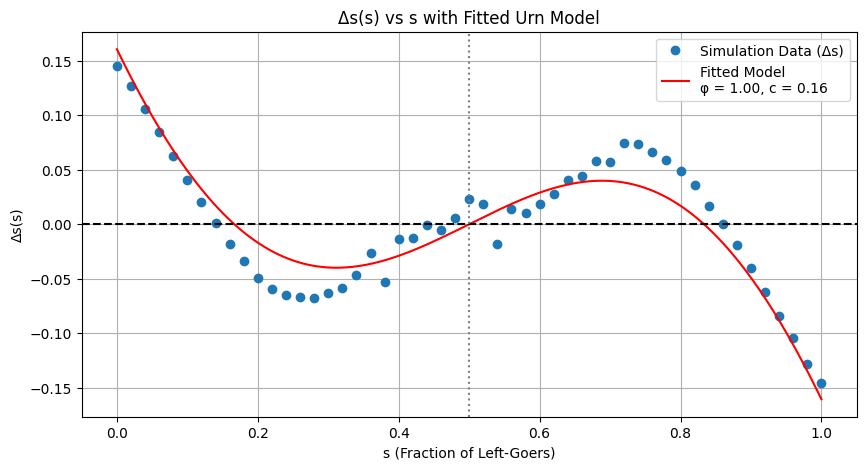

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# -----------------------------
# Load and preprocess data
# -----------------------------
data = np.loadtxt("L_of_L.txt")
L_vals = data[:, 0]
deltaL_vals = data[:, 1]

N = 50
s_vals = L_vals / N
delta_s_vals = deltaL_vals / N  # Convert ΔL to Δs = ΔL / N

# -----------------------------
# Define the model function
# -----------------------------
def delta_s_model(s, phi, c):
    PFB = phi * np.sin(np.pi * s)
    return 4 * c * (PFB - 0.5) * (s - 0.5)

# -----------------------------
# Fit the model to data
# -----------------------------
# Initial guess for phi and c
initial_guess = [0.5, 1.0]
# Bounds: phi in [0, 1], c unbounded
bounds = ([0.0, -np.inf], [1.0, np.inf])

# Fit the function
params, _ = curve_fit(delta_s_model, s_vals, delta_s_vals, p0=initial_guess, bounds=bounds)
phi_fit, c_fit = params

print(f"Fitted φ (phi): {phi_fit:.4f}")
print(f"Fitted c: {c_fit:.4f}")

# -----------------------------
# Generate smooth curves for plotting
# -----------------------------
s_fit = np.linspace(0, 1, 300)
delta_s_fit = delta_s_model(s_fit, phi_fit, c_fit)
PFB_fit = phi_fit * np.sin(np.pi * s_fit)

# -----------------------------
# Plot: Δs(s) with fitted function
# -----------------------------
plt.figure(figsize=(10, 5))
plt.plot(s_vals, delta_s_vals, 'o', label='Simulation Data (Δs)')
plt.plot(s_fit, delta_s_fit, '-', label=f'Fitted Model\nφ = {phi_fit:.2f}, c = {c_fit:.2f}', color='red')
plt.axhline(0, color='black', linestyle='--')
plt.axvline(0.5, color='gray', linestyle=':')
plt.xlabel("s (Fraction of Left-Goers)")
plt.ylabel("Δs(s)")
plt.title("Δs(s) vs s with Fitted Urn Model")
plt.legend()
plt.grid(True)
plt.show()




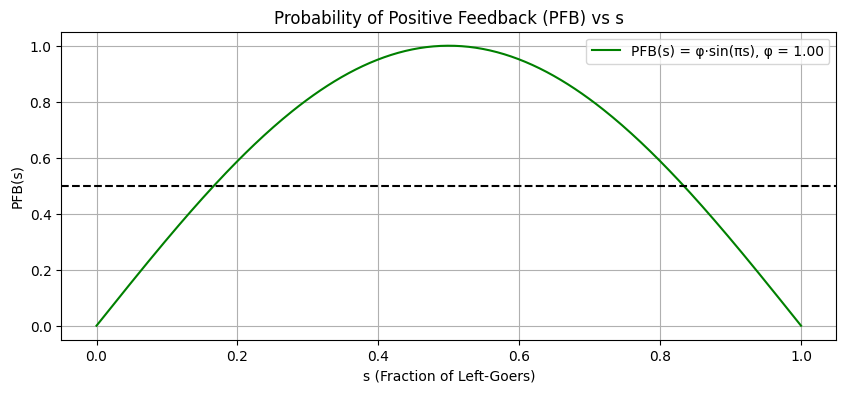

In [4]:
# -----------------------------
# Plot: PFB(s) from fitted φ
# -----------------------------
plt.figure(figsize=(10, 4))
plt.plot(s_fit, PFB_fit, label=f"PFB(s) = φ·sin(πs), φ = {phi_fit:.2f}", color='green')
plt.axhline(0.5, color='black', linestyle='--')
plt.xlabel("s (Fraction of Left-Goers)")
plt.ylabel("PFB(s)")
plt.title("Probability of Positive Feedback (PFB) vs s")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Base Parameters (except N)
C = 0.5
v = 0.01
r = 0.045
P = 0.15
T_total = 10000  # Should be enough for multiple switches
runs_per_N = 30  # Repeat for averaging

# Swarm sizes to test
N_vals = np.arange(20, 155, 10)
avg_switch_times = []
num_switches_list = []

for N in N_vals:
    switch_durations = []

    for run in range(runs_per_N):
        positions = np.random.uniform(0, C, N)
        directions = np.random.choice([-1, 1], N)

        prev_zone = None
        zone_entry = None
        counter = 0

        for t in range(T_total):
            # Movement
            pos_diff = positions[:, None] - positions
            distances = np.abs(pos_diff)
            distances = np.minimum(distances, C - distances)

            influence = np.zeros(N)
            for i in range(N):
                neighbors = distances[i] <= r
                local_sum = np.sum(directions[neighbors])
                if np.random.rand() < P:
                    influence[i] = -directions[i]
                elif local_sum != 0:
                    influence[i] = np.sign(local_sum)
                else:
                    influence[i] = directions[i]

            directions = influence.astype(int)
            positions = (positions + v * directions) % C

            # Count left-goers
            L = np.count_nonzero(directions == -1)

            # Determine current zone
            if L > 0.7 * N:
                zone = "A"
            elif L < 0.3 * N:
                zone = "C"
            else:
                zone = "B"

            # Switch detection logic
            if zone in ["A", "C"]:
                if prev_zone == "B":
                    if zone != zone_entry:  # A → B → C or C → B → A
                        switch_durations.append(counter)
                    counter = 0
                prev_zone = zone
            elif zone == "B":
                if prev_zone in ["A", "C"]:
                    zone_entry = prev_zone  # Remember where we came from
                    counter = 1
                    prev_zone = "B"
                elif prev_zone == "B":
                    counter += 1

    # Stats for this N
    num_switches = len(switch_durations)
    avg_time = np.mean(switch_durations) if num_switches > 0 else np.nan

    avg_switch_times.append(avg_time)
    num_switches_list.append(num_switches)

# ---------------------------
# Plotting results
# ---------------------------

# Plot 1: Average switch time vs swarm size
plt.figure(figsize=(10, 5))
plt.plot(N_vals, avg_switch_times, marker='o', label="Avg. Switch Time")
plt.xlabel("Swarm Size N")
plt.ylabel("Average Switch Time")
plt.title("Switch Time vs Swarm Size")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: Number of switches vs swarm size
plt.figure(figsize=(10, 5))
plt.plot(N_vals, num_switches_list, marker='s', color='orange', label="Switch Count")
plt.xlabel("Swarm Size N")
plt.ylabel("Number of Switches")
plt.title("Number of Switches vs Swarm Size")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
